1. Delete the rows (what if i deleted imp records , it depend also on how many null values are there)
2. Replace with th emost frequent values (what if the data is inbalance then its problem)
3. Apply the classifier algorithm to predict (all data expect categorical feature will be input dataset and predicting the categorical value)
4. Apply Unsupervised ML

***Missing Values***

Lifecycle of a Data Science Projects

Data Collection Statergy---from company side,3rd party APi's,Surveys,Surveys
Feature Engineering---Handling Missing Values

Why are their Missing values?? Survey--Depression Survey

They hesitate to put down the information
Survey informations are not that valid
Men--salary
Women---age
People may have died----NAN
Data Science Projects---Dataset should be collected from multiple sources

What are the different types of Missing Data?

1. Missing Completely at Random, MCAR:
A variable is missing completely at random (MCAR) if the probability of being missing is the same for all the observations. When data is MCAR, there is absolutely no relationship between the data missing and any other values, observed or missing, within the dataset. In other words, those missing data points are a random subset of the data. There is nothing systematic going on that makes some data more likely to be missing than other.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/titanic.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


2. Missing Data Not At Random(MNAR): Systematic missing Values
There is absolutely some relationship between the data missing and any other values, observed or missing, within the dataset.

In [7]:
import numpy as np

In [8]:
df['cabin_null'] = np.where(df['Cabin'].isnull(),1,0)

In [9]:
##find the percentage of null values
df['cabin_null'].mean()

np.float64(0.7710437710437711)

In [14]:
df.groupby(['Survived'])['cabin_null'].mean()


Survived
0    0.876138
1    0.602339
Name: cabin_null, dtype: float64

### All the techniques of handling ,missing values

1. Mean/ Median/Mode replacement
2. Random Sample Imputation (Replace missing value with a random value from existing data (same feature).)
3. Capturing NAN values with a new feature
4. End of Distribution imputation
What is it?

Replace missing with extreme value:
mean+3∗std

Or very large/small number.

🔹 When to Use?

When missing values are meaningful

For skewed features

5. Arbitrary imputation
6. Frequent categories imputation

In [15]:
df.Age.isnull().mean()

np.float64(0.19865319865319866)

In [17]:
df['Age_Median'] = df['Age'].fillna(df.Age.median())
df['Age_Median'] 

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age_Median, Length: 891, dtype: float64

In [18]:
df['Age'].std()

np.float64(14.526497332334042)

In [19]:
df['Age_Median'].std()

np.float64(13.019696550973201)

In [22]:

import matplotlib.pyplot as plt
%matplotlib inline

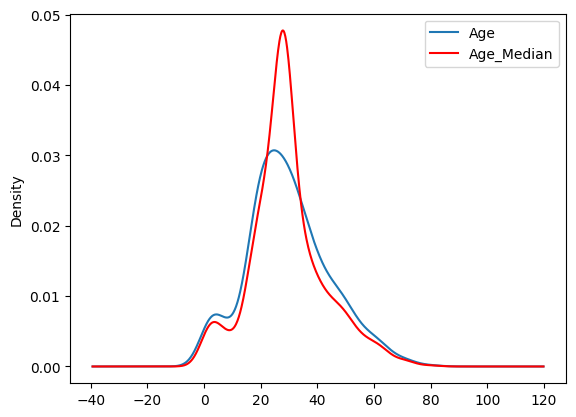

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind='kde',ax=ax)
df.Age_Median.plot(kind='kde',ax=ax,color='red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc = 'best')

***Advantages And Disadvantages of Mean/Median Imputation***

Advantages
Easy to implement(Robust to outliers)
Faster way to obtain the complete dataset

Disadvantages
Change or Distortion in the original variance
Impacts Correlation

🔹 When to Use?
Situation	Use
Data normal	Mean
Data skewed	Median
Categorical	Mode
Missing < 5–10%	Good choice

| Technique | Best For       | Keeps Distribution? | Good for Trees? | Risk                 |
| --------- | -------------- | ------------------- | --------------- | -------------------- |
| Mean      | Normal numeric | ❌                   | ⚠               | Reduces variance     |
| Median    | Skewed numeric | ❌                   | ⚠               | Slight distortion    |
| Mode      | Categorical    | ❌                   | ✔               | Bias toward majority |
| Random    | MCAR numeric   | ✔                   | ✔               | Noise                |
| NaN Flag  | MNAR           | ✔                   | ✔✔              | Extra column         |
| End Dist  | Skewed numeric | ❌                   | ✔✔              | Extreme distortion   |
| Arbitrary | Tree models    | ❌                   | ✔✔              | Bad for linear       |


*Random Sample Imputation*
Aim: Random sample imputation consists of taking random observation from the dataset and we use this observation to replace the nan values

When should it be used? It assumes that the data are missing completely at random(MCAR)

Random sample imputation:
✔ Preserves distribution
✔ Preserves variance
✔ Better than mean for skewed data

In [26]:
import pandas as pd
df = pd.read_csv('data/titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [27]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [28]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [38]:
df['Age'].dropna().sample(df['Age'].isnull().sum(),random_state=0)

423    28.00
177    50.00
305     0.92
292    36.00
889    26.00
       ...  
539    22.00
267    25.00
352    15.00
99     34.00
689    15.00
Name: Age, Length: 177, dtype: float64

In [34]:
df['Age'].isnull().sum()

np.int64(177)

In [36]:
df[df['Age'].isnull()].index

Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
       ...
       832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
      dtype='int64', length=177)

In [46]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)
    df[variable+"_random"]=df[variable]
    ##It will have the random sample to fill the na
    random_sample=df[variable].dropna().sample(df[variable].isnull().sum(),random_state=0)
    ##pandas need to have same index in order to merge the dataset
    random_sample.index=df[df[variable].isnull()].index
    df.loc[df[variable].isnull(),variable+'_random']=random_sample

In [47]:
median = df.Age.median()

In [41]:
median

np.float64(28.0)

In [48]:
impute_nan(df,"Age",median)

In [49]:
df.head()

,Survived,Age,Fare,Age_Median,Age_Random,Age_random,Age_median
0,0,22.0,7.2500,22.0,22.0,22.0,22.0
1,1,38.0,71.2833,38.0,38.0,38.0,38.0
2,1,26.0,7.9250,26.0,26.0,26.0,26.0
3,1,35.0,53.1000,35.0,35.0,35.0,35.0
4,0,35.0,8.0500,35.0,35.0,35.0,35.0


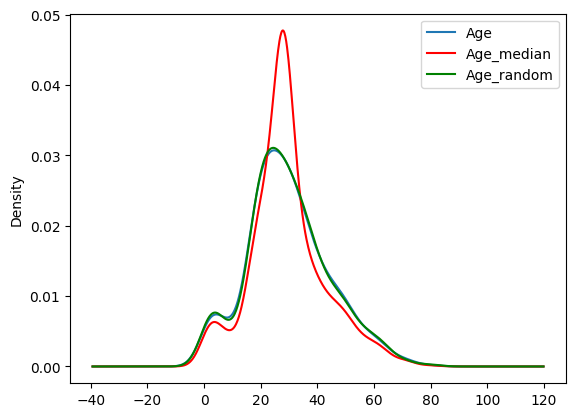

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind='kde', ax=ax)
df.Age_median.plot(kind='kde', ax=ax, color='red')
df.Age_random.plot(kind='kde', ax=ax, color='green')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

*Advantages*
Easy To implement
There is less distortion in variance
*Disadvantage*
Every situation randomness wont work

**Capturing NAN values with a new feature**
It works well if the data are not missing completely at random

In [54]:
df=pd.read_csv('data/titanic.csv', usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [55]:
df['Age_NAN'] = np.where(df['Age'].isnull(),1,0)
df.head()

,Survived,Age,Fare,Age_NAN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0


In [56]:
df.Age.median()

np.float64(28.0)

In [58]:
df['Age'].fillna(df.Age.median(),inplace=True)
df.head()

/tmp/ipykernel_97008/1112226817.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df.Age.median(),inplace=True)


,Survived,Age,Fare,Age_NAN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0


*Advantages*
Easy to implement
Captures the importance of missing values
*Disadvantages*
Creating Additional Features(Curse of Dimensionality)

**End of Distribution imputation**
❌ Problem

Can distort distribution heavily.

In [59]:
df=pd.read_csv('data/titanic.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


<Axes: >

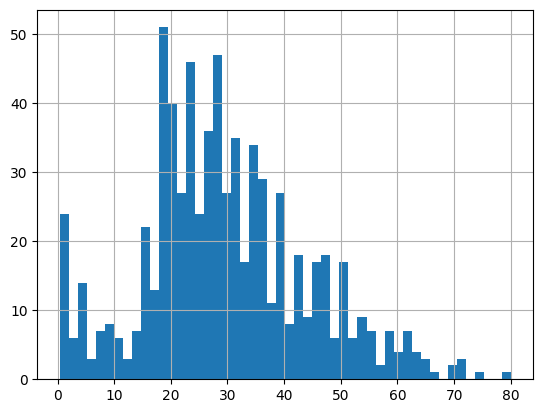

In [60]:
df.Age.hist(bins=50)

In [61]:
extreme = df.Age.mean()+3*df.Age.std()
extreme

np.float64(73.27860964406094)

In [62]:
import seaborn as sns
sns.boxplot('Age',data=df)

TypeError: boxplot() got multiple values for argument 'data'

In [63]:
def impute_nan(df,variable,median,extreme):
    df[variable+"_end_distribution"]=df[variable].fillna(extreme)
    df[variable].fillna(median,inplace=True)

In [64]:
impute_nan(df,'Age',df.Age.median(),extreme)

/tmp/ipykernel_97008/1926933604.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[variable].fillna(median,inplace=True)


In [65]:
df.head()

,Survived,Age,Fare,Age_end_distribution
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


<Axes: >

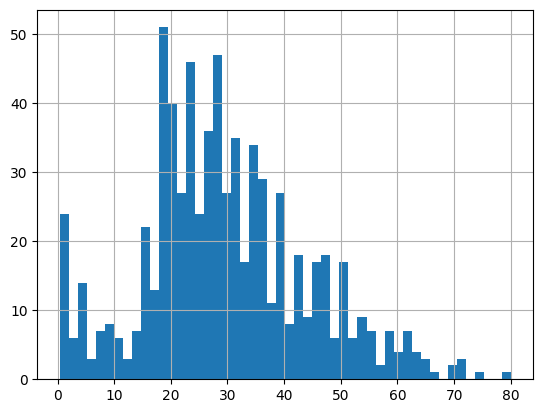

In [66]:
df['Age'].hist(bins=50)

<Axes: >

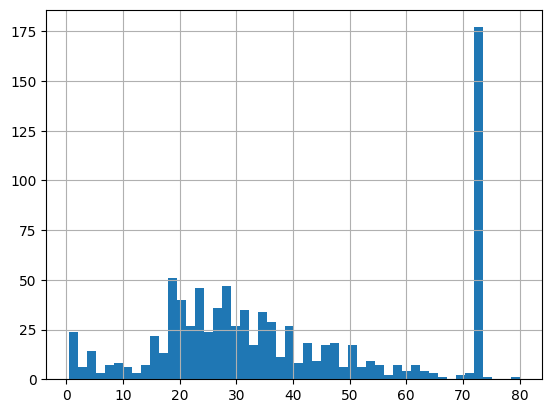

In [67]:
df['Age_end_distribution'].hist(bins=50)

In [68]:
sns.boxplot('Age_end_distribution',data=df)

TypeError: boxplot() got multiple values for argument 'data'

*Arbitrary Value Imputation*this technique was derived from kaggle competition It consists of replacing NAN by an arbitrary value

In [70]:

df=pd.read_csv("data/titanic.csv", usecols=["Age","Fare","Survived"])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [71]:
def impute_nan(df,variable):
    df[variable+'_zero']=df[variable].fillna(0)
    df[variable+'_hundred']=df[variable].fillna(100)

In [74]:
impute_nan(df,'Age')

<Axes: >

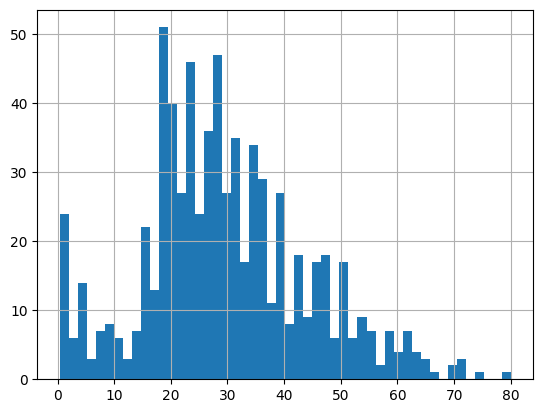

In [72]:
df['Age'].hist(bins=50)

<Axes: >

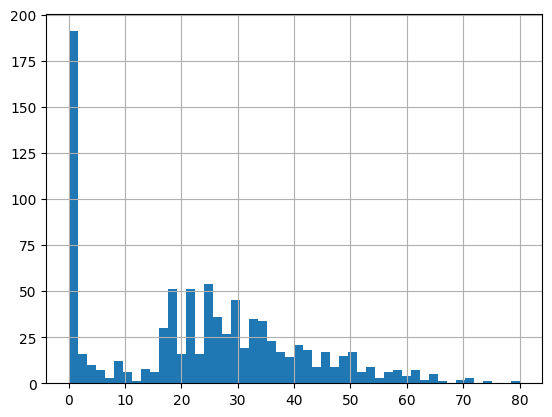

In [75]:
df['Age_zero'].hist(bins=50)

<Axes: >

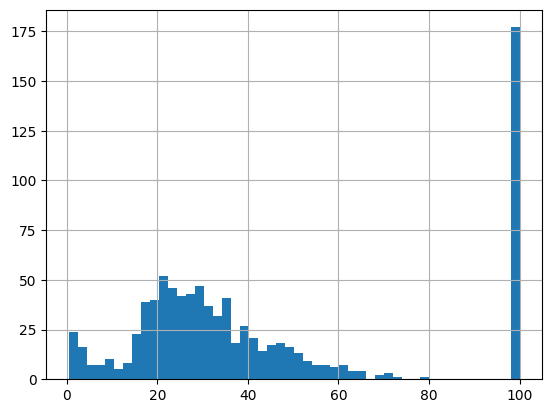

In [76]:
df['Age_hundred'].hist(bins=50)

*Advantages*
Easy to implement
Captures the importance of missingess if there is one
*Disadvantages*
Distorts the original distribution of the variable
If missingess is not important, it may mask the predictive power of the original variable by distorting its distribution
Hard to decide which value to use

*How To Handle Categroical Missing Values*
**Frequent Category Imputation**

In [83]:
df = pd.read_csv('data/mercedesbenz.csv',usecols=['X1','X2','X3'])
df.head()

,X1,X2,X3
0,v,at,a
1,t,av,e
2,w,n,c
3,t,n,f
4,v,n,f


In [84]:
df.isnull().sum()

X1    0
X2    0
X3    0
dtype: int64

In [85]:
df.isnull().mean().sort_values(ascending=False)

X1    0.0
X2    0.0
X3    0.0
dtype: float64

<Axes: xlabel='X1'>

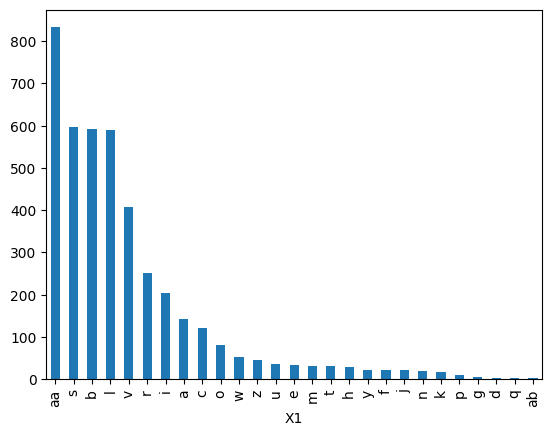

In [87]:
df['X1'].value_counts().plot.bar()

TypeError: Axes.bar() missing 2 required positional arguments: 'x' and 'height'

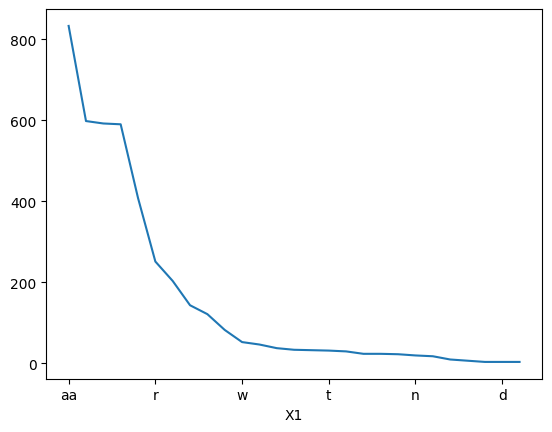

In [88]:
df.groupby(['X1'])['X1'].count().sort_values(ascending=False).plot().bar()

In [90]:
df['X1'].value_counts().index

Index(['aa', 's', 'b', 'l', 'v', 'r', 'i', 'a', 'c', 'o', 'w', 'z', 'u', 'e',
       'm', 't', 'h', 'y', 'f', 'j', 'n', 'k', 'p', 'g', 'd', 'q', 'ab'],
      dtype='str', name='X1')

In [96]:
df['X1'].mode()[0]

'aa'

In [ ]:
def impute_nan(df,variable):
    most_frequent_category=df[variable].mode()[0]
    df[variable].fillna(most_frequent_category,inplace=True)

*Advantages*
Easy To implement
Fater way to implement
*Disadvantages*
Since we are using the more frequent labels, it may use them in an over respresented way, if there are many nan's
It distorts the relation of the most frequent label

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.Age.isnull().sum()

np.int64(177)

In [6]:
df[df['Age'].isnull()].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,177.000000,177.000000,177.000000,0.0,177.000000,177.000000,177.000000
mean,435.581921,0.293785,2.598870,NaN,0.564972,0.180791,22.158567
std,250.552901,0.456787,0.763216,NaN,1.626316,0.534145,31.874608
min,6.000000,0.000000,1.000000,NaN,0.000000,0.000000,0.000000
25%,230.000000,0.000000,3.000000,NaN,0.000000,0.000000,7.750000
50%,452.000000,0.000000,3.000000,NaN,0.000000,0.000000,8.050000
75%,634.000000,1.000000,3.000000,NaN,0.000000,0.000000,24.150000
max,889.000000,1.000000,3.000000,NaN,8.000000,2.000000,227.525000


In [5]:
df[df['Age'].notnull()].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,448.582633,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
std,259.119524,0.491460,0.838250,14.526497,0.929783,0.853289,52.918930
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.250000,0.000000,1.000000,20.125000,0.000000,0.000000,8.050000
50%,445.000000,0.000000,2.000000,28.000000,0.000000,0.000000,15.741700
75%,677.750000,1.000000,3.000000,38.000000,1.000000,1.000000,33.375000
max,891.000000,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
pd.DataFrame(df.groupby('Age')['Survived'].size()).value_counts()

Survived
1           16
2           16
6            6
4            6
3            5
15           4
18           4
10           3
5            3
13           3
25           3
9            3
7            2
8            2
17           2
26           1
24           1
27           1
30           1
23           1
20           1
22           1
11           1
14           1
12           1
Name: count, dtype: int64

In [18]:
df['Age'].isnull().mean()*100

np.float64(19.865319865319865)